# 08 - Interpretar flags PIXC

Este notebook interpreta as variáveis de classe e qualidade do PIXC usado no notebook 07. A etapa transforma proximidade espacial em uma classificação conservadora de suporte observacional, usando prioritariamente os metadados do próprio NetCDF.

## Proximidade espacial versus interpretação do pixel

O notebook 07 mostrou que há pixels PIXC próximos dos 13 exutórios, todos a menos de 500 m. Isso confirma proximidade espacial real, mas ainda não confirma suporte hidrológico: é necessário verificar se a classe do pixel e as flags de qualidade indicam água/observação válida.

## O que são classe e qualidade do pixel

A variável de classe descreve o tipo de pixel identificado no produto PIXC. A variável de qualidade registra flags/condições que podem limitar a confiança na interpretação. Como esses códigos dependem da documentação do produto, o notebook não inventa significados: ele procura `flag_values`, `flag_meanings` e atributos descritivos no NetCDF.

In [1]:
from __future__ import annotations

import json
import logging
import re
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'src' / 'check_environment.py').exists():
            return candidate
    fallback = Path.home() / 'mystorage' / 'PPGGAG1889' / 'atividade3_swot'
    if fallback.exists():
        return fallback
    raise RuntimeError('FALHA: rode este notebook dentro do repositorio atividade3_swot.')

PROJECT_ROOT = find_project_root(Path.cwd())
EXUTORIOS_CSV = PROJECT_ROOT / 'dados' / 'exutorios.csv'
VALIDACAO_PIXC_CSV = PROJECT_ROOT / 'outputs' / 'tabelas' / 'validacao_pixc_controlado_exutorios.csv'
RESUMO_PIXC_CSV = PROJECT_ROOT / 'outputs' / 'tabelas' / 'resumo_pixc_controlado.csv'
PIXC_RAW_DIR = PROJECT_ROOT / 'dados' / 'raw' / 'swot' / 'pixc'
OUTPUT_DICT = PROJECT_ROOT / 'outputs' / 'tabelas' / 'dicionario_flags_pixc.csv'
OUTPUT_VALIDATION = PROJECT_ROOT / 'outputs' / 'tabelas' / 'validacao_pixc_interpretada_exutorios.csv'
OUTPUT_SUMMARY = PROJECT_ROOT / 'outputs' / 'tabelas' / 'resumo_validacao_pixc_interpretada.csv'
OUTPUT_FIGURE = PROJECT_ROOT / 'outputs' / 'figuras' / '08_interpretar_flags_pixc.png'
LOG_FILE = PROJECT_ROOT / 'outputs' / 'logs' / '08_interpretar_flags_pixc.log'

for path in [OUTPUT_DICT.parent, OUTPUT_VALIDATION.parent, OUTPUT_SUMMARY.parent, OUTPUT_FIGURE.parent, LOG_FILE.parent]:
    path.mkdir(parents=True, exist_ok=True)

logging.basicConfig(filename=LOG_FILE, filemode='w', level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
print('OK raiz do projeto:', PROJECT_ROOT)
print('OK log:', LOG_FILE)


OK raiz do projeto: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot
OK log: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/logs/08_interpretar_flags_pixc.log


## Entradas

A célula abaixo lê as tabelas do notebook 07 e localiza o arquivo PIXC `.nc` já baixado. Nenhum novo PIXC ou dado pesado é baixado.

In [3]:
expected_columns = ['id', 'latitude', 'longitude']
for required in [EXUTORIOS_CSV, VALIDACAO_PIXC_CSV, RESUMO_PIXC_CSV]:
    if not required.exists():
        raise FileNotFoundError(f'FALHA: arquivo obrigatorio nao encontrado: {required}')

exutorios = pd.read_csv(EXUTORIOS_CSV)
if list(exutorios.columns) != expected_columns:
    raise ValueError(f'FALHA: colunas esperadas {expected_columns}, colunas encontradas {list(exutorios.columns)}')
if len(exutorios) != 13:
    raise ValueError(f'FALHA: esperados 13 exutorios, encontrados {len(exutorios)}')

validacao_pixc = pd.read_csv(VALIDACAO_PIXC_CSV, dtype={'cycle': str, 'pass': str, 'tile': str})
resumo_pixc = pd.read_csv(RESUMO_PIXC_CSV, dtype={'cycle': str, 'pass': str, 'tile': str})
if resumo_pixc.empty:
    raise ValueError('FALHA: resumo_pixc_controlado.csv esta vazio.')

granule_id = str(resumo_pixc.iloc[0]['granule_id'])
candidates = sorted(PIXC_RAW_DIR.glob(f'{granule_id}*.nc')) + sorted(PIXC_RAW_DIR.glob(f'{granule_id}*.nc4'))
if not candidates:
    candidates = sorted(PIXC_RAW_DIR.glob('*.nc')) + sorted(PIXC_RAW_DIR.glob('*.nc4'))
if not candidates:
    raise FileNotFoundError(f'FALHA: arquivo PIXC .nc nao encontrado em {PIXC_RAW_DIR}. Execute o notebook 07 primeiro neste ambiente.')

nc_path = candidates[0]
logging.info('PIXC selecionado para interpretacao: %s', nc_path)
print('OK validacao PIXC:', len(validacao_pixc))
print('OK resumo PIXC:', len(resumo_pixc))
print('granule_id:', granule_id)
print('arquivo PIXC:', nc_path)
display(validacao_pixc)


OK validacao PIXC: 13
OK resumo PIXC: 1
granule_id: SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_20260829T001621_PID0_01
arquivo PIXC: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/dados/raw/swot/pixc/SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_20260829T001621_PID0_01.nc


,id,latitude,longitude,cycle,pass,tile,granule_id,distancia_m_pixel_pixc,classe_pixel,qualidade_pixel,suporte_pixc,observacoes
0,P01,-15.539765,-47.972069,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,11.28,1,2049,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
1,P02,-15.541334,-47.969589,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,25.67,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
2,P03,-15.541921,-47.981644,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,30.64,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
3,P04,-15.542892,-47.980763,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,24.93,1,3,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
4,P05,-15.542658,-47.979778,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,13.65,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
5,P06,-15.543083,-47.979286,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,12.35,1,3,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
6,P07,-15.541673,-47.979366,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,27.22,2,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
7,P08,-15.537334,-47.975750,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,29.85,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
8,P09,-15.537017,-47.975281,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,6.81,1,2,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
9,P10,-15.536032,-47.976860,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,16.14,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."


## Abertura do NetCDF

O arquivo é aberto com `netCDF4` para inspecionar grupos, variáveis e atributos das flags diretamente na fonte.

In [4]:
try:
    import netCDF4
except Exception as exc:
    logging.exception('Falha ao importar netCDF4')
    raise RuntimeError('FALHA: netCDF4 nao esta instalado no ambiente.') from exc

try:
    import xarray as xr
except Exception as exc:
    logging.warning('xarray nao importado; a interpretacao seguira com netCDF4: %s', exc)
    xr = None

root_nc = netCDF4.Dataset(nc_path, mode='r')
print('grupos:', list(root_nc.groups.keys()))
print('variaveis raiz:', list(root_nc.variables.keys())[:50])
logging.info('Grupos NetCDF: %s', list(root_nc.groups.keys()))


grupos: ['pixel_cloud', 'tvp', 'noise']
variaveis raiz: []


In [5]:
def walk_groups(group, path=''):
    yield path or '/', group
    for name, child in group.groups.items():
        yield from walk_groups(child, f'{path}/{name}' if path else f'/{name}')

def find_var(names: list[str]):
    wanted = {n.lower() for n in names}
    matches = []
    for group_path, group in walk_groups(root_nc):
        for name in group.variables.keys():
            if name.lower() in wanted:
                matches.append((group_path, name))
    preferred_groups = ['/pixel_cloud', '/']
    for pref in preferred_groups:
        for match in matches:
            if match[0] == pref:
                return match
    return matches[0] if matches else (None, None)

def get_group(path: str):
    if path in ['', '/']:
        return root_nc
    group = root_nc
    for part in path.strip('/').split('/'):
        group = group.groups[part]
    return group

lat_group, lat_name = find_var(['latitude', 'lat'])
lon_group, lon_name = find_var(['longitude', 'lon'])
class_group, class_name = find_var(['classification', 'pixel_classification', 'class'])
quality_group, quality_name = find_var(['geolocation_qual', 'sig0_qual', 'classification_qual', 'quality_flag', 'qual', 'pixc_qual'])

if lat_group is None or lon_group is None:
    raise RuntimeError('FALHA: variaveis latitude/longitude nao encontradas no PIXC.')
if class_group is None:
    logging.warning('Variavel de classificacao do pixel nao encontrada por nomes padrao.')
if quality_group is None:
    logging.warning('Variavel de qualidade do pixel nao encontrada por nomes padrao.')

selected_vars = pd.DataFrame([
    {'papel': 'latitude', 'grupo': lat_group, 'variavel': lat_name},
    {'papel': 'longitude', 'grupo': lon_group, 'variavel': lon_name},
    {'papel': 'classe_pixel', 'grupo': class_group, 'variavel': class_name},
    {'papel': 'qualidade_pixel', 'grupo': quality_group, 'variavel': quality_name},
])
print('Variaveis selecionadas:')
display(selected_vars)
logging.info('Variaveis selecionadas: %s', selected_vars.to_dict('records'))


Variaveis selecionadas:


,papel,grupo,variavel
0,latitude,/pixel_cloud,latitude
1,longitude,/pixel_cloud,longitude
2,classe_pixel,/pixel_cloud,classification
3,qualidade_pixel,/pixel_cloud,classification_qual


## Dicionário de flags

A tabela abaixo é construída a partir de atributos do NetCDF como `flag_values`, `flag_masks`, `flag_meanings`, `valid_min`, `valid_max`, `_FillValue`, `long_name`, `units` e descrições. Quando o NetCDF não fornece significado suficiente, isso é registrado claramente.

In [6]:
def attr_dict(var) -> dict:
    return {name: var.getncattr(name) for name in var.ncattrs()}

def normalize_values(values):
    if values is None:
        return []
    arr = np.array(values).ravel()
    out = []
    for item in arr:
        try:
            out.append(int(item))
        except Exception:
            try:
                out.append(float(item))
            except Exception:
                out.append(str(item))
    return out

def normalize_meanings(meanings):
    if meanings is None:
        return []
    if isinstance(meanings, bytes):
        meanings = meanings.decode('utf-8', errors='replace')
    if isinstance(meanings, str):
        return meanings.split()
    return [str(x) for x in np.array(meanings).ravel()]

def build_flag_rows(label: str, group_path: str | None, var_name: str | None):
    if not group_path or not var_name:
        return [{
            'variavel': label,
            'valor': '',
            'significado': '',
            'fonte': 'NetCDF',
            'observacoes': 'Variavel nao encontrada por nomes padrao no arquivo PIXC.',
        }]
    var = get_group(group_path).variables[var_name]
    attrs = attr_dict(var)
    values = normalize_values(attrs.get('flag_values'))
    meanings = normalize_meanings(attrs.get('flag_meanings'))
    common_obs = '; '.join([f'{k}={attrs[k]}' for k in ['long_name', 'standard_name', 'flag_masks', 'valid_min', 'valid_max', '_FillValue', 'units', 'comment', 'description'] if k in attrs])
    rows = []
    if values and meanings and len(values) == len(meanings):
        for value, meaning in zip(values, meanings):
            rows.append({'variavel': label, 'valor': value, 'significado': meaning, 'fonte': f'NetCDF:{group_path}/{var_name}', 'observacoes': common_obs})
    elif values:
        for value in values:
            rows.append({'variavel': label, 'valor': value, 'significado': '', 'fonte': f'NetCDF:{group_path}/{var_name}', 'observacoes': 'flag_values existe, mas flag_meanings ausente/incompativel. Verificar tambem flag_masks quando existir. ' + common_obs})
    else:
        rows.append({'variavel': label, 'valor': '', 'significado': '', 'fonte': f'NetCDF:{group_path}/{var_name}', 'observacoes': 'Sem flag_values/flag_meanings no atributo da variavel. Verificar flag_masks quando existir. ' + common_obs})
    return rows

flag_rows = []
flag_rows.extend(build_flag_rows('classe_pixel', class_group, class_name))
flag_rows.extend(build_flag_rows('qualidade_pixel', quality_group, quality_name))
flag_dict = pd.DataFrame(flag_rows)
flag_dict.to_csv(OUTPUT_DICT, index=False, encoding='utf-8')
logging.info('Dicionario de flags salvo: %s', OUTPUT_DICT)
print('OK dicionario salvo:', OUTPUT_DICT)
display(flag_dict)


OK dicionario salvo: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/tabelas/dicionario_flags_pixc.csv


,variavel,valor,significado,fonte,observacoes
0,classe_pixel,1,land,NetCDF:/pixel_cloud/classification,long_name=classification; valid_min=1; valid_m...
1,classe_pixel,2,land_near_water,NetCDF:/pixel_cloud/classification,long_name=classification; valid_min=1; valid_m...
2,classe_pixel,3,water_near_land,NetCDF:/pixel_cloud/classification,long_name=classification; valid_min=1; valid_m...
3,classe_pixel,4,open_water,NetCDF:/pixel_cloud/classification,long_name=classification; valid_min=1; valid_m...
4,classe_pixel,5,dark_water,NetCDF:/pixel_cloud/classification,long_name=classification; valid_min=1; valid_m...
5,classe_pixel,6,low_coh_water_near_land,NetCDF:/pixel_cloud/classification,long_name=classification; valid_min=1; valid_m...
6,classe_pixel,7,open_low_coh_water,NetCDF:/pixel_cloud/classification,long_name=classification; valid_min=1; valid_m...
7,qualidade_pixel,,,NetCDF:/pixel_cloud/classification_qual,Sem flag_values/flag_meanings no atributo da v...


## Critério conservador de suporte interpretado

`suporte_pixc_interpretado = sim` exige distância menor ou igual a 500 m e flags com significado compatível com água/observação válida. Se a qualidade não puder ser interpretada de forma segura, a classificação permanece `indeterminado`, mesmo com pixel próximo.

In [7]:
def meaning_lookup(flag_df: pd.DataFrame, variable: str) -> dict:
    subset = flag_df[flag_df['variavel'].eq(variable)].copy()
    lookup = {}
    for _, row in subset.iterrows():
        if pd.isna(row['valor']) or str(row['valor']) == '':
            continue
        key = str(int(float(row['valor']))) if re.fullmatch(r'-?\d+(\.0+)?', str(row['valor'])) else str(row['valor'])
        lookup[key] = str(row.get('significado', '') or '')
    return lookup

class_lookup = meaning_lookup(flag_dict, 'classe_pixel')
quality_lookup = meaning_lookup(flag_dict, 'qualidade_pixel')

WATER_TERMS = ['water', 'lake', 'river', 'reservoir', 'open_water', 'dark_water', 'water_near_land']
BAD_TERMS = ['land', 'invalid', 'no_data', 'fill', 'bad', 'not_water']
GOOD_QUALITY_TERMS = ['good', 'valid', 'nominal', 'suspect_false', 'classification_good']
BAD_QUALITY_TERMS = ['bad', 'degraded', 'invalid', 'not_usable', 'suspect', 'qual_bad']

def normalize_code(value):
    if pd.isna(value):
        return None
    try:
        return str(int(float(value)))
    except Exception:
        return str(value)

def infer_support(row):
    dist = pd.to_numeric(row['distancia_m_pixel_pixc'], errors='coerce')
    class_code = normalize_code(row.get('classe_pixel'))
    qual_code = normalize_code(row.get('qualidade_pixel'))
    class_meaning = class_lookup.get(class_code, '') if class_code is not None else ''
    quality_meaning = quality_lookup.get(qual_code, '') if qual_code is not None else ''
    class_text = class_meaning.lower()
    quality_text = quality_meaning.lower()

    if pd.isna(dist) or dist > 500:
        return 'nao', class_meaning, quality_meaning, 'distancia ausente ou maior que 500 m'
    if not class_meaning:
        return 'indeterminado', class_meaning, quality_meaning, 'classe_pixel sem significado documentado no NetCDF'
    if any(term in class_text for term in BAD_TERMS):
        return 'nao', class_meaning, quality_meaning, f'classe_pixel interpretada como incompatível: {class_meaning}'
    class_is_water = any(term in class_text for term in WATER_TERMS)
    if not class_is_water:
        return 'indeterminado', class_meaning, quality_meaning, f'classe_pixel documentada, mas sem termo de agua reconhecido: {class_meaning}'
    if not quality_meaning:
        return 'indeterminado', class_meaning, quality_meaning, 'qualidade_pixel sem significado documentado no NetCDF'
    if any(term in quality_text for term in BAD_QUALITY_TERMS):
        return 'indeterminado', class_meaning, quality_meaning, f'qualidade_pixel exige cautela: {quality_meaning}'
    if any(term in quality_text for term in GOOD_QUALITY_TERMS):
        return 'sim', class_meaning, quality_meaning, 'distancia <= 500 m; classe compativel com agua; qualidade compativel com uso preliminar'
    return 'indeterminado', class_meaning, quality_meaning, f'qualidade_pixel documentada, mas nao categorizada automaticamente: {quality_meaning}'

records = []
for _, row in validacao_pixc.iterrows():
    support, class_meaning, quality_meaning, obs = infer_support(row)
    records.append({
        'id': row['id'],
        'latitude': row['latitude'],
        'longitude': row['longitude'],
        'distancia_m_pixel_pixc': row['distancia_m_pixel_pixc'],
        'classe_pixel': row['classe_pixel'],
        'classe_pixel_significado': class_meaning,
        'qualidade_pixel': row['qualidade_pixel'],
        'qualidade_pixel_significado': quality_meaning,
        'suporte_pixc_interpretado': support,
        'observacoes': obs,
    })

interpreted = pd.DataFrame(records)
interpreted.to_csv(OUTPUT_VALIDATION, index=False, encoding='utf-8')
logging.info('Validacao PIXC interpretada salva: %s', OUTPUT_VALIDATION)
logging.info('Suporte interpretado: %s', interpreted['suporte_pixc_interpretado'].value_counts(dropna=False).to_dict())
print('OK validacao interpretada salva:', OUTPUT_VALIDATION)
print(interpreted['suporte_pixc_interpretado'].value_counts(dropna=False))
display(interpreted)


OK validacao interpretada salva: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/tabelas/validacao_pixc_interpretada_exutorios.csv
suporte_pixc_interpretado
nao    13
Name: count, dtype: int64


,id,latitude,longitude,distancia_m_pixel_pixc,classe_pixel,classe_pixel_significado,qualidade_pixel,qualidade_pixel_significado,suporte_pixc_interpretado,observacoes
0,P01,-15.539765,-47.972069,11.28,1,land,2049,,nao,classe_pixel interpretada como incompatível: land
1,P02,-15.541334,-47.969589,25.67,1,land,1,,nao,classe_pixel interpretada como incompatível: land
2,P03,-15.541921,-47.981644,30.64,1,land,1,,nao,classe_pixel interpretada como incompatível: land
3,P04,-15.542892,-47.980763,24.93,1,land,3,,nao,classe_pixel interpretada como incompatível: land
4,P05,-15.542658,-47.979778,13.65,1,land,1,,nao,classe_pixel interpretada como incompatível: land
5,P06,-15.543083,-47.979286,12.35,1,land,3,,nao,classe_pixel interpretada como incompatível: land
6,P07,-15.541673,-47.979366,27.22,2,land_near_water,1,,nao,classe_pixel interpretada como incompatível: l...
7,P08,-15.537334,-47.975750,29.85,1,land,1,,nao,classe_pixel interpretada como incompatível: land
8,P09,-15.537017,-47.975281,6.81,1,land,2,,nao,classe_pixel interpretada como incompatível: land
9,P10,-15.536032,-47.976860,16.14,1,land,1,,nao,classe_pixel interpretada como incompatível: land


## Resumo quantitativo

A tabela de resumo consolida a contagem de pontos por suporte interpretado, classe e qualidade.

In [8]:
support_counts = interpreted['suporte_pixc_interpretado'].value_counts(dropna=False).to_dict()
class_counts = interpreted['classe_pixel'].value_counts(dropna=False).to_dict()
quality_counts = interpreted['qualidade_pixel'].value_counts(dropna=False).to_dict()
summary = pd.DataFrame([{
    'granule_id': granule_id,
    'n_pontos': len(interpreted),
    'n_sim': int(support_counts.get('sim', 0)),
    'n_nao': int(support_counts.get('nao', 0)),
    'n_indeterminado': int(support_counts.get('indeterminado', 0)),
    'distribuicao_classe_pixel': json.dumps({str(k): int(v) for k, v in class_counts.items()}, ensure_ascii=False),
    'distribuicao_qualidade_pixel': json.dumps({str(k): int(v) for k, v in quality_counts.items()}, ensure_ascii=False),
}])
summary.to_csv(OUTPUT_SUMMARY, index=False, encoding='utf-8')
logging.info('Resumo interpretado salvo: %s', OUTPUT_SUMMARY)
print('OK resumo salvo:', OUTPUT_SUMMARY)
display(summary)


OK resumo salvo: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/tabelas/resumo_validacao_pixc_interpretada.csv


,granule_id,n_pontos,n_sim,n_nao,n_indeterminado,distribuicao_classe_pixel,distribuicao_qualidade_pixel
0,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,13,0,13,0,"{""1"": 12, ""2"": 1}","{""1"": 9, ""3"": 2, ""2049"": 1, ""2"": 1}"


## Figura interpretada

A figura classifica os 13 exutórios por `suporte_pixc_interpretado`. Ela não mostra todos os pixels do PIXC; o foco aqui é a interpretação final por ponto.

OK figura salva: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/figuras/08_interpretar_flags_pixc.png


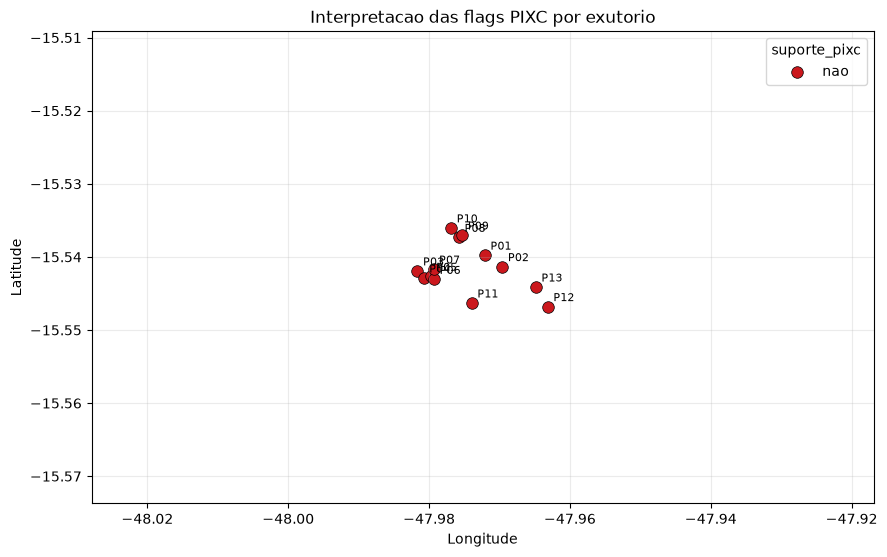

In [9]:
points = gpd.GeoDataFrame(
    interpreted.copy(),
    geometry=gpd.points_from_xy(interpreted['longitude'], interpreted['latitude']),
    crs='EPSG:4326',
)
colors = {'sim': '#238b45', 'nao': '#cb181d', 'indeterminado': '#f0ad00'}
fig, ax = plt.subplots(figsize=(9, 8))
for status, subset in points.groupby('suporte_pixc_interpretado'):
    subset.plot(ax=ax, color=colors.get(status, '#737373'), markersize=70, label=status, edgecolor='black', linewidth=0.5)
for _, row in points.iterrows():
    ax.annotate(row['id'], (row.geometry.x, row.geometry.y), xytext=(4, 4), textcoords='offset points', fontsize=8)
minx, miny, maxx, maxy = points.total_bounds
pad_x = max((maxx - minx) * 2.5, 0.01)
pad_y = max((maxy - miny) * 2.5, 0.01)
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_title('Interpretacao das flags PIXC por exutorio')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='suporte_pixc')
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE, dpi=180)
logging.info('Figura interpretada salva: %s', OUTPUT_FIGURE)
print('OK figura salva:', OUTPUT_FIGURE)
plt.show()


## Limitações

A interpretação depende dos atributos disponíveis no NetCDF. Se `flag_values`, `flag_masks` e `flag_meanings` não estiverem presentes ou forem insuficientes, o notebook mantém a classificação como `indeterminado`. Esta etapa não substitui a leitura formal do manual do produto nem uma avaliação hidrológica completa.

## Recomendação do próximo passo

Se as flags permitirem classificar pontos como `sim`, avançar para recorte e extração de atributos PIXC por exutório. Se permanecer `indeterminado`, buscar a documentação oficial das flags PIXC e atualizar o dicionário de interpretação de forma auditável, sem alterar as distâncias já calculadas.